# Data description
| Variable Name | Description | Type |
|----------|----------|----------|
| SeriousDlqin2yrs | Person experienced 90 days past due delinquency or worse   | Y/N |
| RevolvingUtilizationOfUnsecuredLines | Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits | percentage |
| age | Age of borrower in years |	integer |
| NumberOfTime30-59DaysPastDueNotWorse	| Number of times borrower has been 30-59 days past due but no worse in the last 2 years	| integer |
| DebtRatio	| Monthly debt payments, alimony, living costs divided by monthy gross income |	percentage |
| MonthlyIncome	| Monthly income	| real |
|NumberOfOpenCreditLinesAndLoans	| Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards)	| integer |
|NumberOfTimes90DaysLate	| Number of times borrower has been 90 days or more past due	| integer |
|NumberRealEstateLoansOrLines	| Number of mortgage and real estate loans including home equity lines of credit	| integer |
|NumberOfTime60-89DaysPastDueNotWorse	| Number of times borrower has been 60-89 days past due but no worse in the last 2 years	| integer |
|NumberOfDependents	| Number of dependents in family excluding themselves (spouse, children etc.)	| integer |


**Target: SeriousDlqin2yrs**

# Анализ данных

In [1]:
import pandas as pd
import numpy as np

DATA = pd.read_csv('cs-training.csv')

RANDOM_STATE = 42

In [2]:
DATA.head(3)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


In [3]:
DATA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

В признаках **MonthlyIncome** и **NumberOfDependents** есть много пропущенных значений. Заполним их дальше по ноутбуку.

In [4]:
DATA.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


В данных также присутствуют признаки, которые могут давать схожую информацию: **NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTimes90DaysLate** и **NumberOfTime60-89DaysPastDueNotWorse** или **NumberOfOpenCreditLinesAndLoans** и **NumberRealEstateLoansOrLines**. Посмотрим на их корреляцию по ходу анализа данных.

Также, если мы выделим возраст, который выходит за пределы 18-100 лет, то сможем заметить, что в данных есть явный выброс с возрастом 0 лет, исправим его в зависимости от распределения значений этого признака. Возраст больше 100 лет возможен, так что не будем засчитывать такие значения за выбросы.

In [5]:
DATA.loc[DATA['age'] < 18]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [6]:
DATA.loc[DATA['age'] > 100]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
7763,7764,0,0.069167,101,0,50.000000,NaN,2,0,0,0,0.0
19884,19885,0,1.000000,103,0,0.000000,1600.0,3,0,0,0,0.0
25561,25562,0,0.009866,102,0,0.002424,3300.0,3,0,0,0,0.0
40007,40008,0,0.064748,107,0,939.000000,NaN,9,0,1,0,0.0
56761,56762,0,0.003469,105,0,2.000000,NaN,4,0,0,0,NaN
57967,57968,0,0.001397,103,0,1798.500000,1.0,11,0,2,0,0.0
90937,90938,0,0.000000,102,0,0.000000,NaN,12,0,0,0,0.0
93813,93814,0,0.025780,101,0,0.013797,1666.0,5,0,0,0,0.0
96450,96451,0,0.109642,102,0,0.273844,3417.0,7,0,0,0,1.0
105790,105791,0,0.109307,109,0,2141.000000,NaN,17,0,1,0,NaN


# Итог анализа:

1) Заменить выброс с нулевым возрастом

2) Заполнить пропуски в **NumberOfDependents**

3) Заполнить пропущенные значения в **MonthlyIncome**

4) Исправить возможную корреляцию признаков **NumberOfOpenCreditLinesAndLoans** и **NumberRealEstateLoansOrLines**

5) Исправить возможную корреляцию признаков **NumberOfTime30-59DaysPastDueNotWorse**, **NumberOfTimes90DaysLate** и **NumberOfTime60-89DaysPastDueNotWorse**

6) Создать новые признаки на основе имеющихся

# Обработка данных

## 1) Заменить выброс с нулевым возрастом

Посмотрим на распределение возраста клиентов

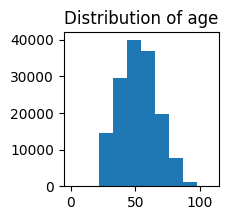

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))
plt.hist(DATA['age'])
plt.title('Distribution of age')
plt.show()

Распределение схоже с нормальным, вполне четким видом колокола. Исходя из распределения заполним пропуски средним возрастом:

In [8]:
mean_age = int(DATA['age'].mean())

DATA['age'] = DATA['age'].replace(0, mean_age)

## 2) Заполнить пропуски в **NumberOfDependents**

In [9]:
DATA['NumberOfDependents'].value_counts(dropna=False)

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
NaN      3924
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
10.0        5
9.0         5
20.0        1
13.0        1
Name: count, dtype: int64

Пропуски заполним модой:

In [10]:
mode_dependents = DATA['NumberOfDependents'].mode()[0]

DATA['NumberOfDependents'] = DATA['NumberOfDependents'].fillna(mode_dependents)

## 3) Заполнить пропущенные значения в **MonthlyIncome**

In [11]:
DATA['MonthlyIncome'].value_counts(dropna=False)

MonthlyIncome
NaN        29731
5000.0      2757
4000.0      2106
6000.0      1934
3000.0      1758
           ...  
16084.0        1
10523.0        1
55250.0        1
9242.0         1
7647.0         1
Name: count, Length: 13595, dtype: int64

Пропусков много, но признак может быть очень полезен для предсказаний. Заполнять пропуским одним значением будет неправильным решением, поскольку ежемесячный доход имеет более сложную зависимость. 

Заполним пропуски предсказаниями другой модели:

In [12]:
X_instance = DATA.loc[DATA['MonthlyIncome'].notna()].drop(columns=['MonthlyIncome', 'SeriousDlqin2yrs'])
X_empty = DATA.loc[DATA['MonthlyIncome'].isna()].drop(columns=['MonthlyIncome', 'SeriousDlqin2yrs'])

y_instance = DATA.loc[DATA['MonthlyIncome'].notna(), 'MonthlyIncome']

Выберем модель для предсказания ежемесячного дохода. Основной метрикой для сравнения будет MSE, так как нам важно штрафовать модель за большие ошибки, поскольку мы добиваемся максимально возможной точности. Для сравнения моделей между собой воспользуемся R2, чтобы оценить их относительно объясненной дисперсией.

In [13]:
import mlflow
import os

os.environ['USER'] = 'Maxim Balabanov'

mlflow.set_tracking_uri("http://localhost:5050")
mlflow.set_experiment('Regressor for MonthlyIncome')

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1756923579093, experiment_id='2', last_update_time=1756923579093, lifecycle_stage='active', name='Regressor for MonthlyIncome', tags={}>

### Линейные модели

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import optuna

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

# Linear Regression
def linear_objective(trial):
    with mlflow.start_run(run_name=f'Linear_trial_{trial.number}', nested=True):
        
        with_mean = trial.suggest_categorical('with_mean', [True, False])
        with_std = trial.suggest_categorical('with_std', [True, False])
        degree = trial.suggest_int('degree', 1, 3)
        
        mlflow.log_params({
            'with_mean': with_mean,
            'with_std': with_std,
            'degree': degree
        })

        pipeline = Pipeline([
        ('Scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('Polynomial Features', PolynomialFeatures(degree=degree)),
        ('Model', LinearRegression())
        ])
        
        preds = cross_val_predict(pipeline, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

# Lasso
def lasso_objective(trial):
    with mlflow.start_run(run_name=f'Lasso_trial_{trial.number}', nested=True):
        
        with_mean = trial.suggest_categorical('with_mean', [True, False])
        with_std = trial.suggest_categorical('with_std', [True, False])
        degree = trial.suggest_int('degree', 1, 3)
        
        alpha = trial.suggest_float('alpha', 0.01, 1)
        
        mlflow.log_params({
            'with_mean': with_mean,
            'with_std': with_std,
            'alpha': alpha,
            'degree': degree
        })
        
        pipeline = Pipeline([
        ('Scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('Polynomial Features', PolynomialFeatures(degree=degree)),
        ('Model', Lasso(alpha=alpha, random_state=RANDOM_STATE))
        ])
        
        preds = cross_val_predict(pipeline, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

# Ridge
def ridge_objective(trial):
    with mlflow.start_run(run_name=f'Ridge_trial_{trial.number}', nested=True):
        
        with_mean = trial.suggest_categorical('with_mean', [True, False])
        with_std = trial.suggest_categorical('with_std', [True, False])
        degree = trial.suggest_int('degree', 1, 3)
        
        alpha = trial.suggest_float('alpha', 0.01, 1)
        
        mlflow.log_params({
            'with_mean': with_mean,
            'with_std': with_std,
            'alpha': alpha,
            'degree': degree
        })
        
        pipeline = Pipeline([
        ('Scaler', StandardScaler(with_mean=with_mean, with_std=with_std)),
        ('Polynomial Features', PolynomialFeatures(degree=degree)),
        ('Model', Ridge(alpha=alpha))
        ])
        
        preds = cross_val_predict(pipeline, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

/Users/bloededhoine/Lands/territory/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#Linear Regression
with mlflow.start_run(run_name='Linear Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(linear_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

#Lasso
with mlflow.start_run(run_name='Lasso Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(lasso_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

#Ridge
with mlflow.start_run(run_name='Ridge Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(ridge_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)

    mlflow.set_tag('Optimizer', 'Optuna')

[I 2025-09-03 22:14:34,117] A new study created in memory with name: no-name-20fd14fe-f20e-40b5-853a-7f125cd4a6e9
[I 2025-09-03 22:14:35,055] Trial 0 finished with value: 428027631.7150457 and parameters: {'with_mean': True, 'with_std': True, 'degree': 2}. Best is trial 0 with value: 428027631.7150457.


🏃 View run Linear_trial_0 at: http://localhost:5050/#/experiments/2/runs/6cfc11ca6a9c4b0dbc0ab0fd19f85cd1
🧪 View experiment at: http://localhost:5050/#/experiments/2


[I 2025-09-03 22:14:38,766] Trial 1 finished with value: 5268266347.63586 and parameters: {'with_mean': True, 'with_std': False, 'degree': 3}. Best is trial 0 with value: 428027631.7150457.


🏃 View run Linear_trial_1 at: http://localhost:5050/#/experiments/2/runs/fa08a331393f4fb3a12d66c91871d815
🧪 View experiment at: http://localhost:5050/#/experiments/2


[I 2025-09-03 22:14:39,242] Trial 2 finished with value: 202398743.3519173 and parameters: {'with_mean': False, 'with_std': True, 'degree': 1}. Best is trial 2 with value: 202398743.3519173.


...

🏃 View run Linear_trial_27 at: http://localhost:5050/#/experiments/2/runs/e70e6b53338d4909b88b42c13c023840
🧪 View experiment at: http://localhost:5050/#/experiments/2


[I 2025-09-03 22:22:08,772] Trial 28 finished with value: 202398743.3519173 and parameters: {'with_mean': False, 'with_std': True, 'degree': 1}. Best is trial 0 with value: 202398743.3519173.


🏃 View run Linear_trial_28 at: http://localhost:5050/#/experiments/2/runs/1b0c9a72d33f43bb9aa1b0a227fc3427
🧪 View experiment at: http://localhost:5050/#/experiments/2


[I 2025-09-03 22:22:11,977] Trial 29 finished with value: 21979973633.81932 and parameters: {'with_mean': False, 'with_std': True, 'degree': 3}. Best is trial 0 with value: 202398743.3519173.


🏃 View run Linear_trial_29 at: http://localhost:5050/#/experiments/2/runs/a398ae94aae449b988e612dca1748d02
🧪 View experiment at: http://localhost:5050/#/experiments/2
🏃 View run Ridge Regressor at: http://localhost:5050/#/experiments/2/runs/2119d65c0c794d649069baaba66e3e06
🧪 View experiment at: http://localhost:5050/#/experiments/2


### Модели деревьев

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

# Gradient Boosting Regression
def gradient_objective(trial):
    with mlflow.start_run(run_name=f'GradientBoosting_trial_{trial.number}', nested=True):
        
        loss = trial.suggest_categorical('loss', ['squared_error', 'absolute_error', 'huber', 'quantile'])
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1)
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        
        mlflow.log_params({
            'loss': loss,
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': max_depth
        })

        model = GradientBoostingRegressor(
            loss=loss,
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth
        )
        
        preds = cross_val_predict(model, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse
    
    # LightGBM Regressor
def lightgbm_objective(trial):
    with mlflow.start_run(run_name=f'LightGBM_trial_{trial.number}', nested=True):
        
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1)
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        
        mlflow.log_params({
            'learning_rate': learning_rate,
            'n_estimators': n_estimators,
            'max_depth': max_depth
        })

        model = LGBMRegressor(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth
        )
        
        preds = cross_val_predict(model, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse
    
    # CatBoost Regressor
def catboost_objective(trial):
    with mlflow.start_run(run_name=f'CatBoost_trial_{trial.number}', nested=True):
        
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1)
        n_estimators = trial.suggest_int('n_estimators', 50, 500)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        
        mlflow.log_params({
            'learning_rate': learning_rate,
            'max_depth': max_depth
        })

        model = CatBoostRegressor(
            learning_rate=learning_rate,
            n_estimators=n_estimators,
            max_depth=max_depth
        )
        
        preds = cross_val_predict(model, X_instance, y_instance, cv=3)
        mse = mean_squared_error(y_instance, preds)
        r2 = r2_score(y_instance, preds)
        
        mlflow.log_metrics({
            'MSE': mse,
            'R2': r2
        }, step=trial.number)
        
        return mse

In [ ]:
#GradientBoosting
with mlflow.start_run(run_name='GradientBoosting Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(gradient_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

#LightGBM
with mlflow.start_run(run_name='LightGBM Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(lightgbm_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)
    
    mlflow.set_tag('Optimizer', 'Optuna')

#CatBoost
with mlflow.start_run(run_name='CatBoost Regressor'):
    study = optuna.create_study(direction='minimize')
    study.optimize(catboost_objective, n_trials=20)
    mlflow.log_metric('mse_best', study.best_value)
    mlflow.log_params(study.best_params)

    mlflow.set_tag('Optimizer', 'Optuna')

# Model Training

В качестве модели возьмем логистическую регрессию с L1-регуляризацией, для этого выберем solver 'saga', так как он поддерживает L1-регуляризацию и рассчитан на большие датасеты. Гиперпараметр 'C' подберем с помощью GridSearch, также установим class_weight 'balanced', так как в данных присутствует дисбаланс классов тагрета:

In [ ]:
plt.figure(figsize=(3, 3))
sns.countplot(x='SeriousDlqin2yrs', data=TRAINING)
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score, confusion_matrix

import mlflow
import optuna
from optuna.integration import MLflowCallback

In [ ]:
import os
os.environ['USER'] = 'Maxim Balabanov'

In [ ]:
tracking_uri = 'http://localhost:5050'
experiment_name = 'GradientBoosting as Classifier'
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(experiment_name)

В качестве метрики выберем f1-score, поскольку нам необходимо в равной степени иметь высокие recall и precision. Также, так как в данных присутсвует дисбаланс классов, f1 в отличие от roc-auc будет честнее оценивать предсказательную способность модели.

In [ ]:
def objective_gradient(trial):
    with mlflow.start_run(run_name=f'Trial_№{trial.number}', nested=True):
        loss = trial.suggest_categorical('loss', ['log_loss', 'exponential'])
        learning_rate = trial.suggest_float('learning_rate', 0.01, 1)
        n_estimators = trial.suggest_int('n_estimators', 100, 1000)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        max_depth = trial.suggest_int('max_depth', 2, 16)
        
        model = GradientBoostingClassifier(
            loss=loss, 
            learning_rate=learning_rate, 
            n_estimators=n_estimators, 
            criterion=criterion,
            max_depth=max_depth
            )
        
        pred = cross_val_predict(model, X_train, y_train, cv=3)
        
        f1 = f1_score(y_train, pred)
        
        metrics = {
        'f1': f1,
        'roc_auc': roc_auc_score(y_train, pred),
        'recall': recall_score(y_train, pred),
        'precision': precision_score(y_train, pred)
        }
        
        mlflow.log_metrics(metrics, step=trial.number)
        mlflow.log_params(trial.params)
        
        return f1

In [ ]:
with mlflow.start_run(run_name='Gradient_run'):
    study = optuna.create_study(direction='maximize')
    study.optimize(objective_gradient, n_trials=10)

    params = study.best_params
    mlflow.log_params(params)
    mlflow.log_metric('f1', study.best_value)
    mlflow.sklearn.log_model(GradientBoostingClassifier(**params), f'Gradient_f1_{study.best_value:.2}')
    mlflow.set_tags({
        'optimizer': 'optuna',
        'main_metric': 'f1'
    })

In [ ]:
def 

f1 показывает не самый хороший результат. Попробуем другие модели:

RandomForest и GradientBoosting очень зависимы от гиперпараметров, для ускорения их подбора воспользуемся не GridSearch, а Optuna

In [ ]:
# objective для RandomForest
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 500)
    max_depth = trial.suggest_int('max_depth', 2, 10)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])
    
    model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, criterion=criterion, random_state=RANDOM_STATE)
    
    return cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40, show_progress_bar=True)

score_forest = study.best_value

In [ ]:
# objective для GradientBoosting
def gradient_objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 10, 500)
    max_depth = trial.suggest_int('max_depth', 2, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 1)
    
    model = GradientBoostingClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate, random_state=RANDOM_STATE)
    
    return cross_val_score(model, X_train, y_train, cv=3, scoring='f1', n_jobs=-1).mean()

In [ ]:
study_gradient = optuna.create_study(direction='maximize')
study_gradient.optimize(gradient_objective, n_trials=40, show_progress_bar=True)

score_gradient = study_gradient.best_value